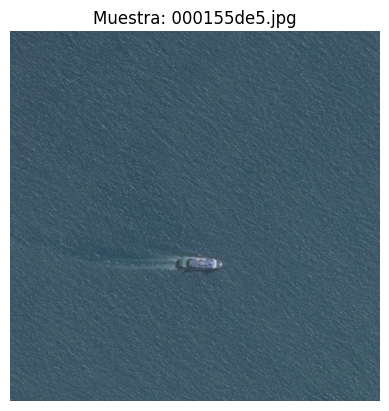

In [1]:
import numpy as np # linear algebra
import os
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from sklearn.model_selection import train_test_split
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn
from torchvision import tv_tensors
import torchvision.transforms.v2 as T2
import torch.nn.functional as F
from tqdm import tqdm  # CORREGIDO: era 'from tqmd import tqmd' (modulo/funcion inexistentes)
import torch.optim as optim

CSV_PATH = '/kaggle/input/competitions/airbus-ship-detection/train_ship_segmentations_v2.csv'
TRAIN_IMG_PATH = '/kaggle/input/competitions/airbus-ship-detection/train_v2'

df = pd.read_csv(CSV_PATH)
img_sample = df.iloc[2]
img_sample_path = os.path.join(TRAIN_IMG_PATH, img_sample['ImageId'])

img = Image.open(img_sample_path)
plt.imshow(img)
plt.title(f"Muestra: {img_sample['ImageId']}")
plt.axis('off')
plt.show()

In [2]:
df['has_ship'] = df['EncodedPixels'].notnull().astype(int)
df_images = df.groupby('ImageId').agg({'has_ship':'max', 'EncodedPixels':'count'}).reset_index()
df_images.rename(columns={'EncodedPixels': 'Total_ships'}, inplace=True)
df_images_ships = df_images[df_images['has_ship'] == 1]
df_images_nships = df_images[df_images['has_ship'] == 0]
print(f'El numero de imagenes con barco es:{len(df_images_ships)}')
print(f'El numero de imagenes sin barco es:{len(df_images_nships)}')

El numero de imagenes con barco es:42556
El numero de imagenes sin barco es:150000


In [3]:
# we need to balance de data before to build the dataset,
# we are going to do 2 experiments with and without the balanced data
# we're taking 50/50
df_no_ships_sample = df_images_nships.sample(n=len(df_images_ships), random_state=42)
# concatenamos y mezclamos (usamos sample para mezclar)
df_balanced = pd.concat([df_images_ships, df_no_ships_sample]).sample(frac=1, random_state=42).reset_index(drop=True)
df_unbalanced = df_images

In [4]:
# We set up the dataset in pytorch
class AirbusDataset(Dataset):
    def __init__(self, df, image_dir_path, transform=None):
        self.df = df
        self.image_path = image_dir_path
        self.transformations = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df['ImageId'].iloc[idx]
        img_path = os.path.join(self.image_path, img_name)
        # pasamos la clase a un tensor
        img_class = int(self.df['has_ship'].iloc[idx])
        label = torch.tensor(img_class, dtype=torch.float32)

        image = Image.open(img_path).convert('RGB')

        # transformaciones
        if self.transformations:
            image = self.transformations(image)

        return image, label

In [5]:
# definimos las transformaciones
train_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# separacion de train, test
# PRIMER EXPERIMENTO CON DATA BALANCEADA
train_df, val_df = train_test_split(df_balanced, test_size=0.2, stratify=df_balanced['has_ship'], random_state=42)

# instanciamos el dataset y el dataloader
train_dataset = AirbusDataset(train_df, TRAIN_IMG_PATH, train_transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)

images, labels = next(iter(train_loader))
print(f'Dimensiones del lote de imagenes: {images.shape}')
print(f'Dimensiones del lote de etiquetas: {labels.shape}')

Dimensiones del lote de imagenes: torch.Size([32, 3, 224, 224])
Dimensiones del lote de etiquetas: torch.Size([32])


In [6]:
# creamos la red, vamos a usar un resnet50
# para esta red no se va a congelar el backbone debido a que Imagenet (base de datos sobre la cual se entreno ResNet)
# es buena para reconocer estructuras, texturas lo que se vio en Amazon from space, mas no es adecuada para identificar
# imagenes de barcos en el mar.
class AirbusClassifier(nn.Module):
    def __init__(self):
        super(AirbusClassifier, self).__init__()
        # descargamos la red con sus pesos
        self.backbone = resnet50(weights=ResNet50_Weights.DEFAULT)

        # features de entrada
        in_features = self.backbone.fc.in_features

        # reemplazamos la ultima capa
        self.backbone.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x)

# instanciamos el clasificador
model = AirbusClassifier()
print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s] 


AirbusClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(


In [7]:
# simulamos un tensor para comprobar la salida de la red
mock_images = torch.randn(4, 3, 224, 224)
model.eval()
with torch.no_grad():
    mock_output = model(mock_images)

print(f'Dimensiones de entrada: {mock_images.shape}')
print(f'Dimensiones de salida: {mock_output.shape}')

Dimensiones de entrada: torch.Size([4, 3, 224, 224])
Dimensiones de salida: torch.Size([4, 1])


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# pasamos el modelo al dispositivo
model.to(device)

# funcion de perdida: mide el error entre logits y etiquetas (incluye la sigmoide internamente)
criterion = nn.BCEWithLogitsLoss()
# optimizador (determina como ajustar los pesos para tratar de minimizar el error)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# definimos la funcion de entrenamiento
def classifier_train(model, data_loader, criterion, optimizer, device, epochs=2):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct_preds = 0  # reseteo por epoca
        total_preds = 0    # reseteo por epoca

        print(f"\n--- Iniciando Epoca {epoch + 1}/{epochs} ---")
        for batch_idx, (image, label) in enumerate(data_loader):
            image = image.to(device)
            label = label.unsqueeze(1).to(device)  # dim = [batch, 1]

            optimizer.zero_grad()
            outputs = model(image)
            loss = criterion(outputs, label)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * image.size(0)  # suma de la perdida por imagen del lote
            model_pred = (outputs > 0.0).float()  # pasamos de logits a un vector de 0 y 1
            correct_preds += (model_pred == label).sum().item()  # 1 si coinciden, la suma da las pred correctas
            total_preds += label.size(0)  # total de elementos de cada batch

            if batch_idx % 50 == 0:
                print(f'Lote {batch_idx}/{len(data_loader)}, perdida actual: {loss.item():.4f}')

        # CORREGIDO: se divide por el numero TOTAL de imagenes (len del dataset), no por el numero de lotes.
        # Como arriba se acumulo loss.item()*image.size(0) (suma por imagen), esto da la media por imagen.
        epoch_loss = running_loss / len(data_loader.dataset)
        epoch_acc = correct_preds / total_preds  # normalizacion
        print(f'==> Epoca {epoch+1}: perdida por epoca={epoch_loss:.4f} | accuracy={epoch_acc:.4f} <==')

classifier_train(model, train_loader, criterion, optimizer, device, epochs=2)


--- Iniciando Epoca 1/2 ---
Lote 0/2128, perdida actual: 0.6938
Lote 50/2128, perdida actual: 0.5898
Lote 100/2128, perdida actual: 0.5131
Lote 150/2128, perdida actual: 0.3695
Lote 200/2128, perdida actual: 0.4340
Lote 250/2128, perdida actual: 0.1593
Lote 300/2128, perdida actual: 0.2369
Lote 350/2128, perdida actual: 0.1434
Lote 400/2128, perdida actual: 0.2030
Lote 450/2128, perdida actual: 0.4214
Lote 500/2128, perdida actual: 0.2367
Lote 550/2128, perdida actual: 0.3537
Lote 600/2128, perdida actual: 0.2110
Lote 650/2128, perdida actual: 0.2412
Lote 700/2128, perdida actual: 0.1058
Lote 750/2128, perdida actual: 0.1740
Lote 800/2128, perdida actual: 0.2093
Lote 850/2128, perdida actual: 0.2542
Lote 900/2128, perdida actual: 0.1245
Lote 950/2128, perdida actual: 0.2287
Lote 1000/2128, perdida actual: 0.2913
Lote 1050/2128, perdida actual: 0.2414
Lote 1100/2128, perdida actual: 0.1965
Lote 1150/2128, perdida actual: 0.2749
Lote 1200/2128, perdida actual: 0.1900
Lote 1250/2128, per

## Seccion de segmentacion de las imagenes.

In [9]:
# Debemos definir una funcion para leer el RLE (la forma en como vienen dados los pixeles de la imagen), dado que esta
# en texto plano, debemos crear una funcion que reconstruya la imagen de forma tensorial para que sea manipulable por
# pytorch. Usaremos operaciones vectorizadas de numpy para la tarea.
import numpy as np

def rle_decode(mask_rle, shape=(768, 768)):
    # CORREGIDO: trabajamos sobre un vector PLANO (el RLE indexa sobre la imagen aplanada, no sobre filas)
    ocean = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    # uniformamos: un solo string o una lista de strings
    mask_rles = [mask_rle] if isinstance(mask_rle, str) else mask_rle

    for masks in mask_rles:              # correccion: iteramos sobre mask_rles, no sobre mask_rle
        if pd.isna(masks):
            continue

        s = masks.split()               # correccion: era 'rle.split' (variable inexistente y sin parentesis)
        # extraemos indices y longitudes para reconstruir la matriz
        starts = np.asarray(s[0:][::2], dtype=int) - 1
        lengths = np.asarray(s[1:][::2], dtype=int)  
        ends = starts + lengths

        for lo, hi in zip(starts, ends):
            ocean[lo:hi] = 1

    # 'Reconstruimos' la imagen considerando que el dataset de airbus esta codificado en Fortran
    return ocean.reshape(shape, order='F')  # era 'final_mask' (variable inexistente)

In [10]:
# definimos el dataframe que vamos a usar en el dataset.
df_with_ships = df[df['EncodedPixels'].notnull()]  # la columna es 'EncodedPixels', no 'Encoded_Pixels'

df_list = df_with_ships.groupby('ImageId')['EncodedPixels'].apply(list).reset_index()

class AirbusSegmentationDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df['ImageId'].iloc[idx]
        mask_encoded = self.df['EncodedPixels'].iloc[idx]  #  nombre de columna
        img_path = os.path.join(self.img_dir, img_name)    #  era 'os.join'

        image = Image.open(img_path).convert('RGB')
        # aplicamos la funcion de decode
        mask_decoded = rle_decode(mask_encoded, shape=(768, 768))
        mask = tv_tensors.Mask(mask_decoded)

        if self.transform:
            image, mask = self.transform(image, mask)

        return image, mask

# Definimos las transformaciones que se aplican a imagen y mascara con T2 (v2)
transforms = T2.Compose([
    T2.Resize((256, 256)),
    T2.RandomHorizontalFlip(p=0.5),
    T2.ToImage(),
    T2.ToDtype(torch.float32, scale=True),  # solo escala la imagen, no la mascara
    T2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# El data-augmentation no crea filas nuevas: en cada epoca __getitem__ aplica una transformacion aleatoria
# distinta. El numero de muestras por epoca sigue siendo len(df_list); el "aumento" ocurre a lo largo del entrenamiento.
train_df_seg, test_df_seg = train_test_split(df_list, test_size=0.2, random_state=42)

# instanciamos los datasets y los dataloaders
train_seg_dataset = AirbusSegmentationDataset(train_df_seg, TRAIN_IMG_PATH, transforms)
train_seg_dataloader = DataLoader(train_seg_dataset, batch_size=16, shuffle=True, num_workers=2)  # CORREGIDO: era 'Dataloader'

print(f'Imagenes listas para el entrenamiento de segmentacion: {len(train_seg_dataset)}')

Imagenes listas para el entrenamiento de segmentacion: 34044


In [11]:
# comprobacion de las dimensiones
images, masks = next(iter(train_seg_dataloader))

print(f'Dimension del batch de imagenes {images.shape}')  # era 'image.shapes'
print(f'Dimension del batch de mascaras {masks.shape}')   # era 'masks.shapes' 

Dimension del batch de imagenes torch.Size([16, 3, 256, 256])
Dimension del batch de mascaras torch.Size([16, 256, 256])


In [12]:
# Diseno de la UNet (una rama que reduce lo espacial y aumenta caracteristicas, y otra que
# aumenta lo espacial mientras reduce las caracteristicas)

# Doble convolucion que se repite en encoder y decoder
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),  # sin bias porque BatchNorm ya lo aporta
            nn.BatchNorm2d(out_channels),  # normalizamos por el internal covariate shift
            nn.ReLU(inplace=True),        
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),  #entra out_channels, no in_channels
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)          # CORREGIDO: era nn.ReLu
        )

    def forward(self, x):
        return self.conv(x)

# Clase UNet que usa DoubleConv
class Unet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(Unet, self).__init__()
        self.ups = nn.ModuleList()    # capas del decoder
        self.downs = nn.ModuleList()  # capas del encoder
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # reduce la resolucion espacial a la mitad

        # encoder
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # decoder: reconstruimos la dimension espacial y concatenamos la skip connection;
        # la concatenacion duplica los canales, por eso la DoubleConv siguiente los vuelve a reducir.
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2) 
            )
            self.ups.append(
                DoubleConv(feature * 2, feature)
            )

        # cuello de botella
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        # capa final: 1x1 conv para producir logits crudos (sin ReLU/BatchNorm, que impedirian valores negativos)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)  # CORREGIDO: era DoubleConv(features[0], out_features)

    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]  # de la mas pequena a la mas grande
        # las capas de ups van como convT - DoubleConv - convT - DoubleConv ...
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx // 2]
            x_concat = torch.cat((skip_connection, x), dim=1)  # concatenamos por canales
            x = self.ups[idx + 1](x_concat)                    # aplicamos la DoubleConv

        return self.final_conv(x)  

# Instanciamos y verificamos
unet_model = Unet(in_channels=3, out_channels=1)  
print("Instanciacion completa")

Instanciacion completa


In [13]:
# probamos el funcionamiento de la red
mock_batch = torch.randn(4, 3, 256, 256)
unet_model.eval()
with torch.no_grad():
    output = unet_model(mock_batch)

print(f'Dimensiones de entrada: {mock_batch.shape}')
print(f'Dimensiones de salida: {output.shape}')

Dimensiones de entrada: torch.Size([4, 3, 256, 256])
Dimensiones de salida: torch.Size([4, 1, 256, 256])


In [14]:
# Funcion de perdida que considera el desbalance de PIXELES (mucho oceano ~10000 vs poco barco ~300).
# Combinamos BCE (pixel a pixel) con Dice (superposicion de la mascara predicha y la real).
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super(BCEDiceLoss, self).__init__()
        self.bce_weight = bce_weight
        self.bce_loss = nn.BCEWithLogitsLoss()  

    def forward(self, inputs, target):
        # BCE pixel a pixel (sobre los logits)
        bce_loss = self.bce_loss(inputs, target)
        # Dice: pasamos logits a probabilidades
        inputs_prob = torch.sigmoid(inputs)
        # aplanamos para comparar
        inputs_prob = inputs_prob.view(-1)   
        target = target.view(-1)             
        # coeficiente DICE
        dice_coef = 2 * ((inputs_prob * target).sum() + 1e-6) / (inputs_prob.sum() + target.sum() + 1e-6)
        dice_loss = 1 - dice_coef
        # Corregido, la parte BCE se pondera con bce_loss (antes se sumaba dice_coef por error)
        return (1 - self.bce_weight) * dice_loss + self.bce_weight * bce_loss

# instanciacion de la perdida
criterion_seg = BCEDiceLoss(bce_weight=0.5)

In [15]:
# bucle de entrenamiento de la segmentacion
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
unet_model.to(device)

optimizer_seg = optim.Adam(unet_model.parameters(), lr=1e-4)
seg_epochs = 3

for epoch in range(seg_epochs):
    unet_model.train()
    running_loss = 0.0
    print(f"\n--- Iniciando Epoca {epoch + 1}/{seg_epochs} ---")

    for batch_idx, (images, masks) in enumerate(train_seg_dataloader):
        images = images.to(device)
        masks = masks.float().to(device)
        if masks.dim() == 3:               # [B, H, W] -> [B, 1, H, W] para calzar con la salida de la UNet
            masks = masks.unsqueeze(1)

        optimizer_seg.zero_grad()
        outputs = unet_model(images)
        loss = criterion_seg(outputs, masks)
        loss.backward()
        optimizer_seg.step()

        running_loss += loss.item() * images.size(0)
        if batch_idx % 50 == 0:
            print(f'Lote {batch_idx}/{len(train_seg_dataloader)}, perdida actual: {loss.item():.4f}')

    epoch_loss = running_loss / len(train_seg_dataloader.dataset)  # media por imagen
    print(f'==> Epoca {epoch+1}: perdida por epoca={epoch_loss:.4f} <==')


--- Iniciando Epoca 1/3 ---
Lote 0/2128, perdida actual: 0.8224
Lote 50/2128, perdida actual: 0.6708
Lote 100/2128, perdida actual: 0.6248
Lote 150/2128, perdida actual: 0.6013
Lote 200/2128, perdida actual: 0.5956
Lote 250/2128, perdida actual: 0.5849
Lote 300/2128, perdida actual: 0.5780
Lote 350/2128, perdida actual: 0.5877
Lote 400/2128, perdida actual: 0.5570
Lote 450/2128, perdida actual: 0.5642
Lote 500/2128, perdida actual: 0.5428
Lote 550/2128, perdida actual: 0.5499
Lote 600/2128, perdida actual: 0.5278
Lote 650/2128, perdida actual: 0.5256
Lote 700/2128, perdida actual: 0.5103
Lote 750/2128, perdida actual: 0.4873
Lote 800/2128, perdida actual: 0.4973
Lote 850/2128, perdida actual: 0.5152
Lote 900/2128, perdida actual: 0.4631
Lote 950/2128, perdida actual: 0.4572
Lote 1000/2128, perdida actual: 0.4599
Lote 1050/2128, perdida actual: 0.4387
Lote 1100/2128, perdida actual: 0.4482
Lote 1150/2128, perdida actual: 0.4225
Lote 1200/2128, perdida actual: 0.4023
Lote 1250/2128, per

In [16]:
# =====================================================================
# GUARDAR PESOS DE LOS MODELOS (Clasificador y Segmentador UNet)
# =====================================================================
import torch

# 1. Guardar pesos del Clasificador (ResNet50)
torch.save(model.state_dict(), 'airbus_classifier_resnet50.pth')
print("✅ Pesos del clasificador guardados exitosamente en 'airbus_classifier_resnet50.pth'")

# 2. Guardar pesos de la UNet (Segmentación)
torch.save(unet_model.state_dict(), 'airbus_unet_model.pth')
print("✅ Pesos de la UNet guardados exitosamente en 'airbus_unet_model.pth'")

# 3. (Opcional) Guardar Checkpoint completo con estado del optimizador para reanudar el entrenamiento en Kaggle
checkpoint = {
    'epoch': seg_epochs,
    'model_state_dict': unet_model.state_dict(),
    'optimizer_state_dict': optimizer_seg.state_dict(),
    'loss': epoch_loss,
}
torch.save(checkpoint, 'unet_checkpoint_complete.pth')
print("✅ Checkpoint completo guardado en 'unet_checkpoint_complete.pth'")

✅ Pesos del clasificador guardados exitosamente en 'airbus_classifier_resnet50.pth'
✅ Pesos de la UNet guardados exitosamente en 'airbus_unet_model.pth'
✅ Checkpoint completo guardado en 'unet_checkpoint_complete.pth'


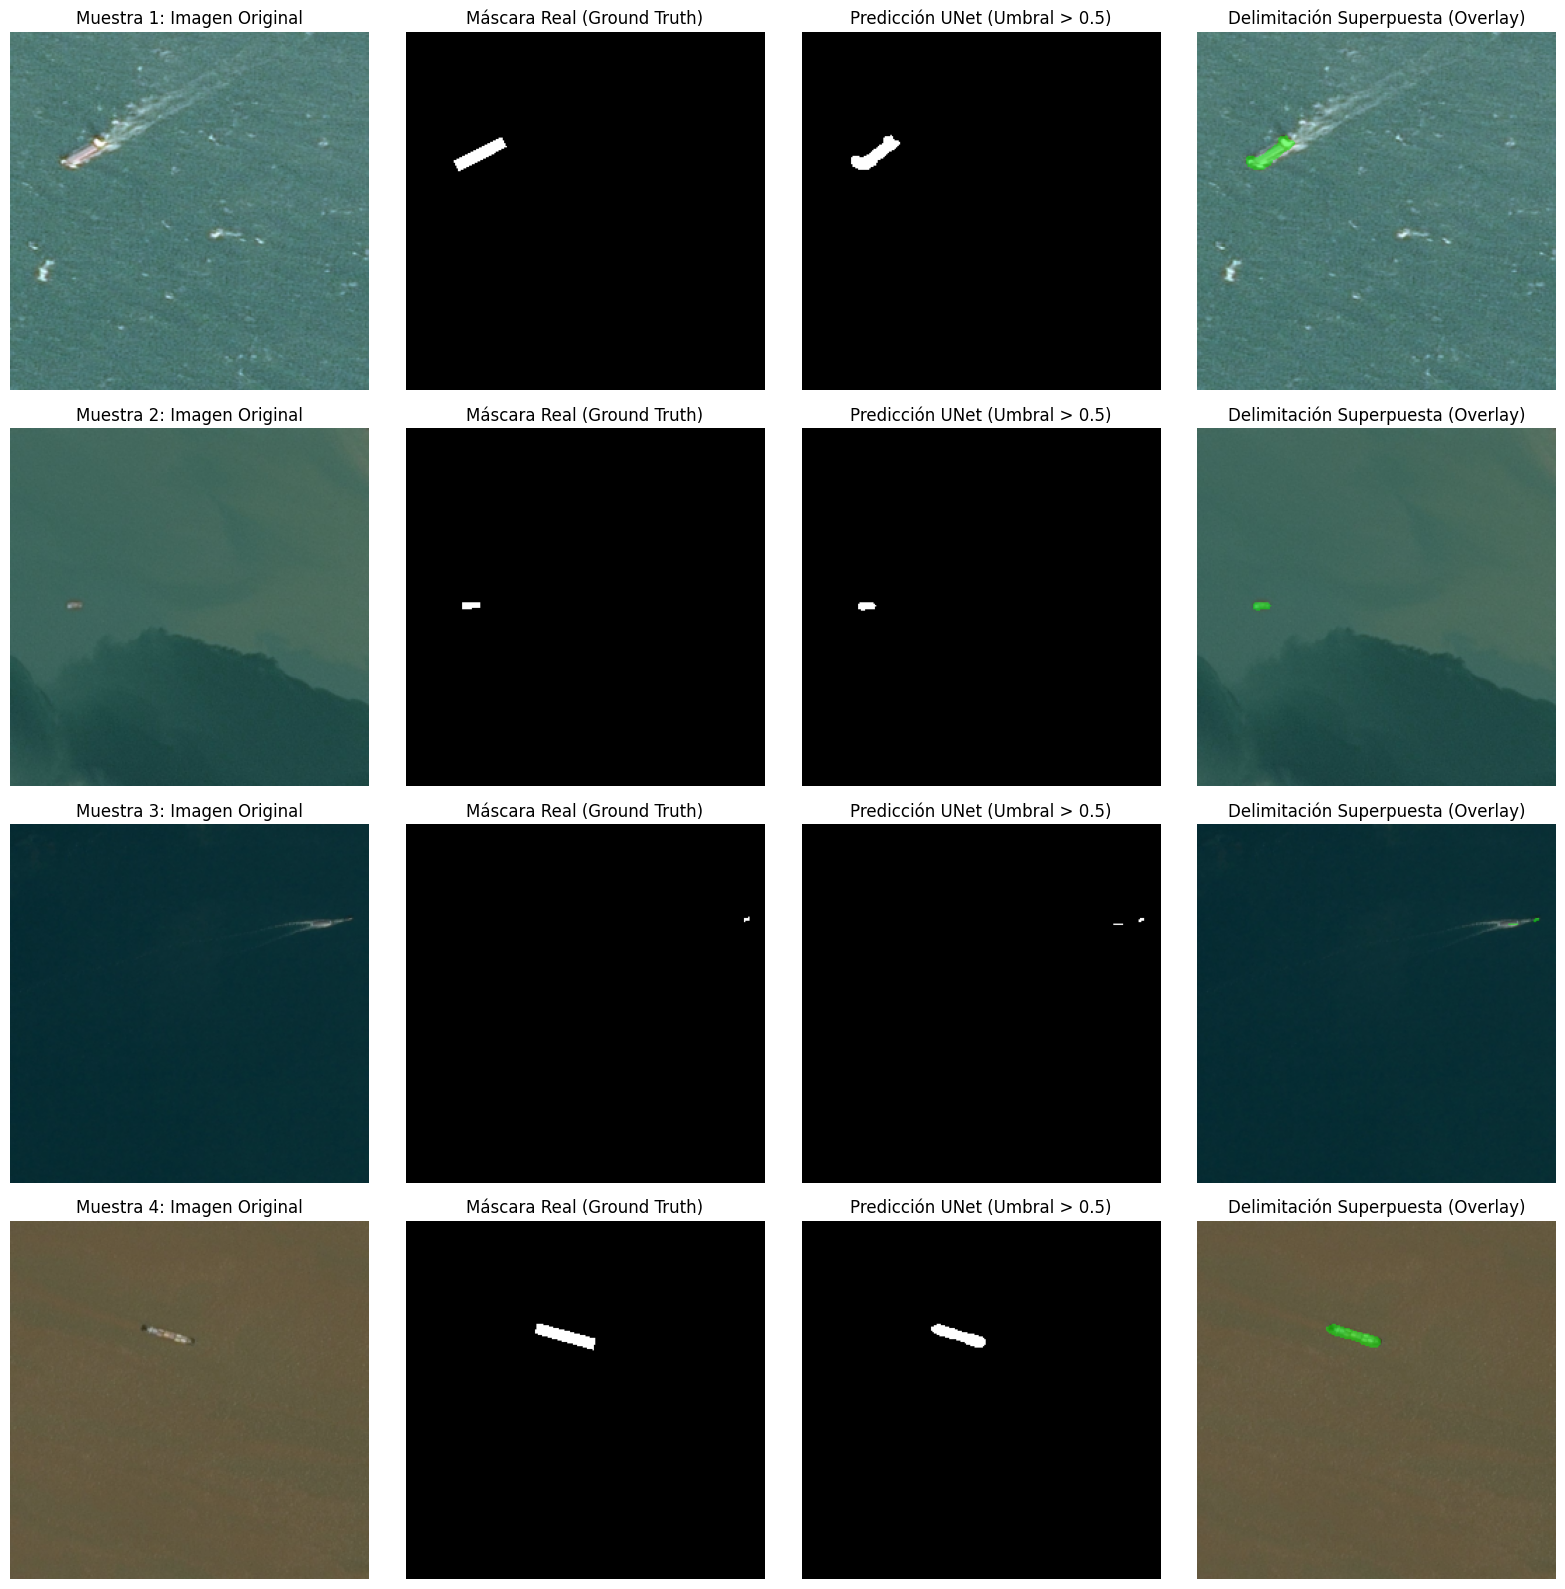

In [17]:
# =========================================================================
# CELDA: VISUALIZACIÓN GRÁFICA DE PREDICCIONES DE SEGMENTACIÓN (VALIDACIÓN)
# =========================================================================
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms.v2 as T2
from torch.utils.data import DataLoader

# 1. Transformaciones de Validacion (SIN aumentacion aleatoria de datos)
val_transforms = T2.Compose([
    T2.Resize((256, 256)),
    T2.ToImage(),
    T2.ToDtype(torch.float32, scale=True),
    T2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Instanciamos el dataset de validacion utilizando 'test_df_seg'
val_seg_dataset = AirbusSegmentationDataset(test_df_seg, TRAIN_IMG_PATH, val_transforms)
val_seg_dataloader = DataLoader(val_seg_dataset, batch_size=8, shuffle=True)

# 3. Funcion para des-normalizar tensores RGB a matriz numpy [0, 1]
def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.cpu().numpy().transpose((1, 2, 0))
    img = std * img + mean
    return np.clip(img, 0, 1)

# 4. Función de inferencia y graficación
def visualize_unet_predictions(model, dataloader, device, num_samples=4, threshold=0.5):
    model.eval()
    
    # Obtenemos un lote del dataloader de validacion
    images, masks = next(iter(dataloader))
    images_gpu = images.to(device)
    
    with torch.no_grad():
        logits = model(images_gpu)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

    num_samples = min(num_samples, len(images))
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))
    
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(num_samples):
        img_np = denormalize(images[i])
        gt_mask = masks[i].cpu().numpy().squeeze()
        pred_mask = preds[i].cpu().numpy().squeeze()
        prob_map = probs[i].cpu().numpy().squeeze()

        # Columna 1: Imagen Satelital Original
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f"Muestra {i+1}: Imagen Original")
        axes[i, 0].axis('off')

        # Columna 2: Máscara Real (Ground Truth)
        axes[i, 1].imshow(gt_mask, cmap='gray')
        axes[i, 1].set_title("Máscara Real (Ground Truth)")
        axes[i, 1].axis('off')

        # Columna 3: Máscara Predicha por la UNet
        axes[i, 2].imshow(pred_mask, cmap='gray')
        axes[i, 2].set_title(f"Predicción UNet (Umbral > {threshold})")
        axes[i, 2].axis('off')

        # Columna 4: Delimitación Superpuesta (Overlay) en Verde
        axes[i, 3].imshow(img_np)
        overlay = np.zeros((*pred_mask.shape, 4))
        overlay[..., 1] = 1.0               # Canal Verde (RGB)
        overlay[..., 3] = pred_mask * 0.5   # Transparencia Alpha al 50%
        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title("Delimitación Superpuesta (Overlay)")
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()

# Ejemplo de ejecución mostrando 4 imágenes de validación
visualize_unet_predictions(unet_model, val_seg_dataloader, device, num_samples=4, threshold=0.5)

In [ ]:
# =========================================================================
# CELDA: EVALUACIÓN DE MÉTRICAS DE SEGMENTACIÓN (F2 SCORE, IoU, DICE)
# =========================================================================
import torch
import numpy as np

def calculate_segmentation_metrics(model, dataloader, device, threshold=0.5, eps=1e-7):
    """
    Calcula las métricas de evaluación acumuladas a nivel de píxel:
    - F2 Score (Prioriza el Recall frente a Falsos Negativos)
    - IoU / Jaccard Index (Solapamiento)
    - Dice / F1-Score
    - Precision y Recall
    """
    model.eval()
    
    total_tp = 0  # Verdaderos Positivos (Píxeles de barco detectados correctamente)
    total_fp = 0  # Falsos Positivos (Falsa alarma / olas detectadas como barco)
    total_fn = 0  # Falsos Negativos (Barcos reales que la red omitió)
    total_tn = 0  # Verdaderos Negativos (Océano correctamente clasificado)

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device).float()
            if masks.dim() == 3:
                masks = masks.unsqueeze(1)

            # Inferencia y calculo de probabilidades mediante Sigmoide
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float()

            # Aplanamos los tensores a 1D por batch
            preds_flat = preds.view(-1)
            masks_flat = masks.view(-1)

            # Contadores de matriz de confusión píxel a píxel
            tp = (preds_flat * masks_flat).sum().item()
            fp = (preds_flat * (1.0 - masks_flat)).sum().item()
            fn = ((1.0 - preds_flat) * masks_flat).sum().item()
            tn = ((1.0 - preds_flat) * (1.0 - masks_flat)).sum().item()

            total_tp += tp
            total_fp += fp
            total_fn += fn
            total_tn += tn

    # 1. Precisión = TP / (TP + FP)
    precision = total_tp / (total_tp + total_fp + eps)
    
    # 2. Recall = TP / (TP + FN)
    recall = total_tp / (total_tp + total_fn + eps)
    
    # 3. IoU (Intersection over Union) = TP / (TP + FP + FN)
    iou = total_tp / (total_tp + total_fp + total_fn + eps)
    
    # 4. Dice Score (F1) = 2*TP / (2*TP + FP + FN)
    dice = (2 * total_tp) / (2 * total_tp + total_fp + total_fn + eps)
    
    # 5. F2 Score = 5 * (Precision * Recall) / (4 * Precision + Recall)
    # Forma equivalente directa desde matriz de confusión:
    f2_score = (5 * total_tp) / (5 * total_tp + 4 * total_fn + total_fp + eps)

    return {
        "F2_Score": f2_score,
        "IoU_Jaccard": iou,
        "Dice_F1": dice,
        "Precision": precision,
        "Recall": recall,
        "TP_pixels": int(total_tp),
        "FP_pixels": int(total_fp),
        "FN_pixels": int(total_fn)
    }

print("🔍 Calculando métricas de segmentación sobre el conjunto de validación...")
metrics = calculate_segmentation_metrics(unet_model, val_seg_dataloader, device, threshold=0.5)

print("\n" + "="*50)
print("INFORME DE EVALUACIÓN DE LA UNet (AIRBUS SHIP SEGMENTATION)")
print("="*50)
print(f" F2 Score (Métrica Oficial) : {metrics['F2_Score']:.4f}")
print(f" IoU (Jaccard Index)        : {metrics['IoU_Jaccard']:.4f}")
print(f" Dice Score (F1)            : {metrics['Dice_F1']:.4f}")
print(f" Recall (Sensibilidad)      : {metrics['Recall']:.4f}")
print(f" Precisión                  : {metrics['Precision']:.4f}")
print("-" * 50)
print(f" Píxeles de barco acertados (TP) : {metrics['TP_pixels']:,}")
print(f" Píxeles de barco omitidos (FN) : {metrics['FN_pixels']:,}")
print(f" Falsas alarmas (FP)            : {metrics['FP_pixels']:,}")
print("="*50)

🔍 Calculando métricas de segmentación sobre el conjunto de validación...

📊 INFORME DE EVALUACIÓN DE LA UNet (AIRBUS SHIP SEGMENTATION)
🎯 F2 Score (Métrica Oficial) : 0.7726
📐 IoU (Jaccard Index)        : 0.6545
🎲 Dice Score (F1)            : 0.7912
🔍 Recall (Sensibilidad)      : 0.7607
🎯 Precisión                  : 0.8243
--------------------------------------------------
🔹 Píxeles de barco acertados (TP) : 2,182,838
⚠️ Píxeles de barco omitidos (FN) : 686,838
❌ Falsas alarmas (FP)            : 465,244
